In [335]:
import mofr

In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
from support_functions import calculate_MACD, calculate_lead_lag_triggers, calculate_regression_model_price
tol=(1e-1)/2

import seaborn as sns


In [337]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [338]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [339]:
import warnings
warnings.filterwarnings('ignore')

In [340]:
max_secs_between_trades=60
cluster_trade_num_threshold=5
min_price_movement=0.05

burnout_period=30
stop_profit=0.3
makeagg_ratio=0.6

take_profit=1
stop_loss=-1

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [341]:
##########################
param_dict = {}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

param_dict['br_fee'] = br_fee
##########################


strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.param_dict=param_dict

# Data preparation

In [342]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_july.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_july.csv',
                    parse_dates=['datetime']).reset_index()

In [343]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [344]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [345]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [346]:
data_lag['date']=data_lag['datetime'].apply(lambda x: x.date())

In [347]:
data_lag['timestamp']=data_lag['datetime']
data_lead['timestamp']=data_lead['datetime']

data_lag=calculate_MACD(data_lag)
data_lag=calculate_lead_lag_triggers(data_lead, data_lag, max_secs_between_trades, cluster_trade_num_threshold, min_price_movement)
data_lead=calculate_regression_model_price(data_lead, data_lag, 10, 10, 3)

        
data_lag['tag']='lag'
data_lead['tag']='lead'

data_lead['bid_price']=None
data_lead['ask_price']=None
data_lead['mid_price']=None

data_lag= pd.concat([data_lag, data_lead[['bid_price', 'ask_price', 'mid_price','datetime', 'timestamp', 'tag', 'trd_price', 'lag_price_predicted', 'lag_price_predicted_datetime', 'lag_price_tick', 'coef1', 'coef2', 'lead_price_tick']].reset_index(drop=True)]).reset_index(
    drop=True).sort_values('datetime')

# Convert the timestamp to date and set it as a separate column if not already done
data_lag['date'] = data_lag['datetime'].dt.date

# Forward fill within each day
data_lag['bid_price'] = data_lag.groupby('date')['bid_price'].ffill()
data_lag['ask_price'] = data_lag.groupby('date')['ask_price'].ffill()
data_lag['mid_price'] = data_lag.groupby('date')['mid_price'].ffill()
data_lag['MACD'] = data_lag.groupby('date')['MACD'].ffill()

data_lag=data_lag.dropna(subset=['bid_price', 'ask_price', 'mid_price'])

In [348]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff,date,...,MACD,trigger_datetime,trigger_action,tag,lag_price_predicted,lag_price_predicted_datetime,lag_price_tick,coef1,coef2,lead_price_tick
0,469.0,2024-07-01 09:00:06.000000000,NaN,NaN,84.57,85.59,85.08,1.0,7.000000,2024-07-01,...,NaN,NaT,NaN,lag,NaN,NaT,NaN,NaN,NaN,NaN
1,470.0,2024-07-01 09:00:07.000000000,NaN,NaN,84.59,85.59,85.09,1.0,1.000000,2024-07-01,...,NaN,NaT,NaN,lag,NaN,NaT,NaN,NaN,NaN,NaN
2,471.0,2024-07-01 09:00:08.673907280,85.59,2.0,84.59,85.59,85.09,1.0,1.673907,2024-07-01,...,0.0,NaT,NaN,lag,NaN,NaT,NaN,NaN,NaN,NaN
3,472.0,2024-07-01 09:00:09.000000000,NaN,NaN,84.61,85.59,85.10,1.0,0.326093,2024-07-01,...,0.0,NaT,NaN,lag,NaN,NaT,NaN,NaN,NaN,NaN
4,473.0,2024-07-01 09:00:10.124257326,85.59,1.0,84.61,85.59,85.10,1.0,1.124257,2024-07-01,...,0.0,NaT,NaN,lag,NaN,NaT,NaN,NaN,NaN,NaN


# Target Calculation

In [349]:
def calculate_close_slot_long(open_price, open_time, row):
    
        if (row['ask_price']-row['bid_price']>param_dict['ba_max']) or row['tag']!='lag':
            return (0,0)
    
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        strategy_class.tag=row['tag']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=1
        
        return strategy_class.calculate_close_slot()
    
def calculate_close_slot_short(open_price, open_time, row):

        if row['ask_price']-row['bid_price']>param_dict['ba_max'] or row['tag']!='lag':
            return (0,0)
        
        strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument='m2',
                            is_overnight=False,
                            closing_mode=closing_mode)

        strategy_class.param_dict=param_dict
        
        strategy_class.timestamp_ = row['datetime']
        strategy_class.mid_p = row['mid_price']
        strategy_class.bid_p = row['bid_price']
        strategy_class.ask_p = row['ask_price']
        strategy_class.trd_p = row['trd_price']
        strategy_class.trd_s = row['trd_side']
        strategy_class.time_diff=row['time_diff']
        strategy_class.tag=row['tag']
        
        strategy_class.position_dict['open_price']=open_price
        strategy_class.position_dict['volume']=-1
        strategy_class.position_dict['open_time']=open_time
        
        strategy_class._position=-1
        
        return strategy_class.calculate_close_slot()

    
def calculate_profit_long(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['ask_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_long(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return price-open_price-2*param_dict['br_fee']
    
    return 0

def calculate_profit_short(row, df):
    
    if row['ask_price']-row['bid_price']>param_dict['ba_max']:
        return None
    
    open_price=row['bid_price']
    open_time=row['datetime']
    
    filtered_df=df[(df['date']==row['date'])&(df['datetime']>row['datetime'])]
    
    for index, row in filtered_df.iterrows():
        price,vol = calculate_close_slot_short(open_price, open_time, row)
        
        if price!=0 and vol!=0:
            return open_price-price-2*param_dict['br_fee']
    
    return 0

In [350]:
df_filtered=data_lag[data_lag['tag']=='lead']

In [351]:
for date in sorted(list(set(df_filtered.date))):
    print(date)
    a=data_lag[data_lag['date']==date]
    df_filtered.loc[df_filtered['date']==date, 'profit_long']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_long(row, a), axis=1)
    df_filtered.loc[df_filtered['date']==date, 'profit_short']=df_filtered.loc[df_filtered['date']==date][['datetime', 'date', 'bid_price', 'ask_price']].apply(lambda row: calculate_profit_short(row, a), axis=1)

2024-07-01
2024-07-02
2024-07-03
2024-07-04
2024-07-05
2024-07-08
2024-07-09
2024-07-10
2024-07-11
2024-07-12
2024-07-15
2024-07-16
2024-07-17
2024-07-18
2024-07-19
2024-07-22
2024-07-23
2024-07-24
2024-07-25
2024-07-26
2024-07-29
2024-07-30
2024-07-31


In [352]:
df_filtered=df_filtered[df_filtered['datetime'].apply(lambda x: x.hour>8 and  x.hour<17)]

In [353]:
df_filtered.to_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_oot_may_june_enriched.csv')

# Model Calculation

In [354]:
seed=2

In [355]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

## Long model 

In [356]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['ask_price']

In [357]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
#fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [358]:
df_modelling=df_filtered[fil1&fil2&fil4]

### Regression

In [359]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff']]
y_train = df_modelling['profit_long'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            profit_long   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     368.3
Date:                Tue, 27 Aug 2024   Prob (F-statistic):          2.48e-158
Time:                        10:35:57   Log-Likelihood:                -6001.3
No. Observations:               24500   AIC:                         1.201e+04
Df Residuals:                   24497   BIC:                         1.203e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0452      0.002    -19.225      0.0

### XGBoost

In [360]:
df_modelling['y']=(df_modelling['profit_long']>0).apply(int)
df_modelling['y'].value_counts()

y
0    15197
1     9303
Name: count, dtype: int64

In [361]:
feature_cols=['MACD', 'price_diff']

In [362]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

xgb_model.save_model('xgboost_model_dem2_dem1_jan_feb_long.json')

In [363]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.8473208275087876
The gini on the df set is: 0.35547363188269365
The accuracy on the df set is: 0.6565442176870748


The Lift on the test set is: 1.7803162422974073
The gini on the test set is: 0.32122698457702326
The accuracy on the test set is: 0.6460408163265307




In [364]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,0.115750
1,price_diff,0.168802


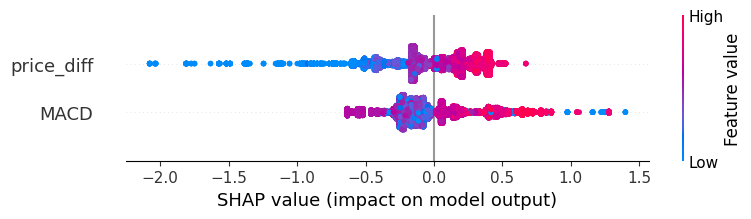

In [365]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

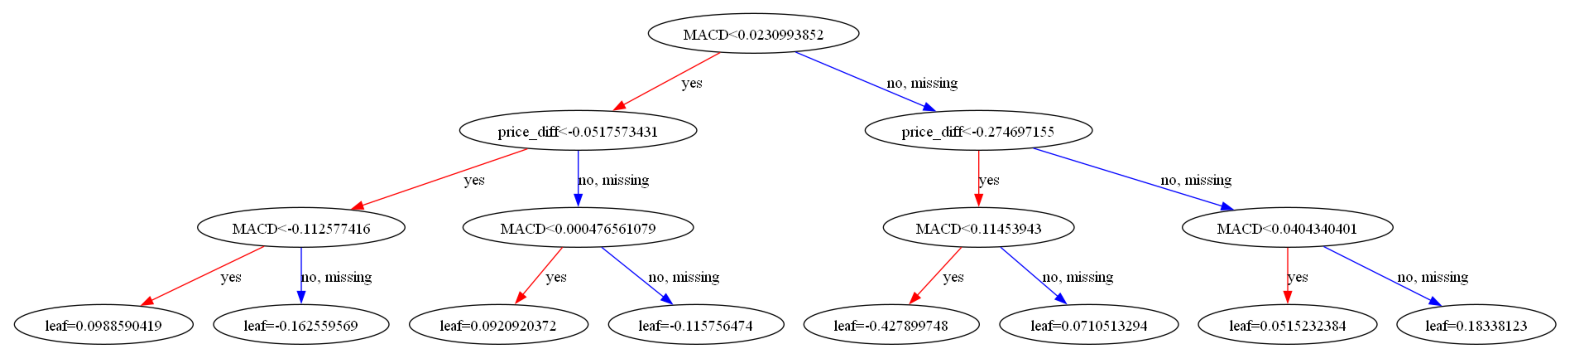

In [366]:
fig, ax = plt.subplots(figsize=(20, 20))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='UT', ax=ax)
plt.show()

#### **Precision curve**

In [367]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.6, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [368]:
prec_recall_df[-50:]

,thold,precision,recall,count
350,0.550,0.658996,0.135893,478
351,0.551,0.658996,0.135893,478
352,0.552,0.658996,0.135893,478
353,0.553,0.658996,0.135893,478
354,0.554,0.658996,0.135893,478
355,0.555,0.658996,0.135893,478
356,0.556,0.658898,0.134167,472
357,0.557,0.658898,0.134167,472
358,0.558,0.647383,0.101381,363
359,0.559,0.650000,0.100949,360


### Interactions

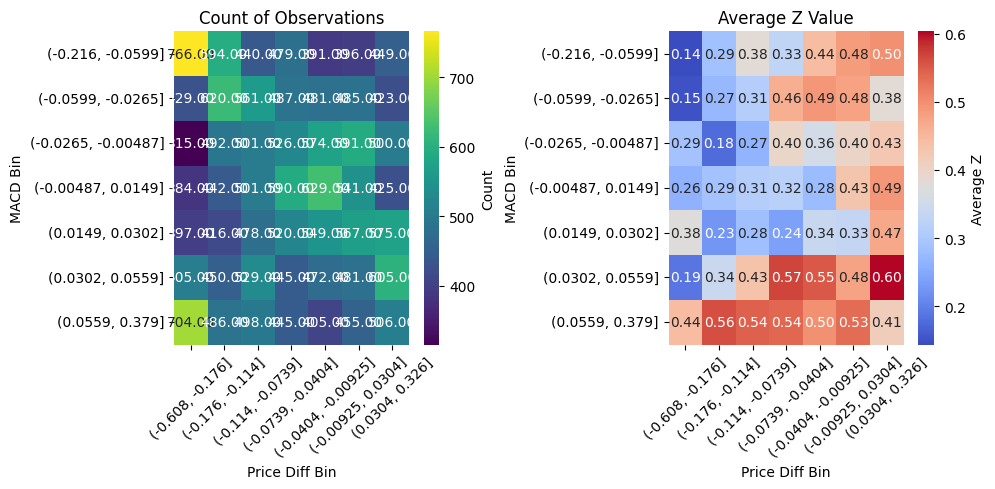

In [369]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'],7, retbins=False, precision=3)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=3)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='count')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [370]:
count_pivot

price_diff_bin,"(-0.608, -0.176]","(-0.176, -0.114]","(-0.114, -0.0739]","(-0.0739, -0.0404]","(-0.0404, -0.00925]","(-0.00925, 0.0304]","(0.0304, 0.326]"
MACD_bin,,,,,,,
"(-0.216, -0.0599]",766,594,440,479,391,396,449
"(-0.0599, -0.0265]",429,620,561,487,481,485,423
"(-0.0265, -0.00487]",315,492,501,526,574,591,500
"(-0.00487, 0.0149]",384,442,501,590,629,541,425
"(0.0149, 0.0302]",397,416,478,520,549,567,575
"(0.0302, 0.0559]",505,450,529,445,472,481,605
"(0.0559, 0.379]",704,486,498,445,405,455,506


In [371]:
mean_pivot

price_diff_bin,"(-0.608, -0.176]","(-0.176, -0.114]","(-0.114, -0.0739]","(-0.0739, -0.0404]","(-0.0404, -0.00925]","(-0.00925, 0.0304]","(0.0304, 0.326]"
MACD_bin,,,,,,,
"(-0.216, -0.0599]",0.143603,0.286195,0.384091,0.327766,0.442455,0.484848,0.498886
"(-0.0599, -0.0265]",0.149184,0.272581,0.311943,0.462012,0.490644,0.478351,0.382979
"(-0.0265, -0.00487]",0.288889,0.176829,0.265469,0.397338,0.357143,0.399323,0.426000
"(-0.00487, 0.0149]",0.260417,0.287330,0.311377,0.316949,0.276630,0.430684,0.491765
"(0.0149, 0.0302]",0.375315,0.225962,0.282427,0.238462,0.338798,0.333333,0.471304
"(0.0302, 0.0559]",0.188119,0.342222,0.432892,0.568539,0.552966,0.476091,0.603306
"(0.0559, 0.379]",0.444602,0.561728,0.544177,0.539326,0.498765,0.534066,0.413043


## Short model 

In [372]:
df_filtered['price_diff']=df_filtered['lag_price_predicted']-df_filtered['bid_price']

In [373]:
fil1=df_filtered['MACD'].isnull()==False
fil2=df_filtered['price_diff'].isnull()==False
#fil3=df_filtered['trigger_action'].isnull()==False
fil4=df_filtered['profit_long'].isnull()==False

In [374]:
df_modelling=df_filtered[fil1&fil2&fil4]

In [375]:
# Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
X_train = df_modelling[['MACD', 'price_diff']]
y_train = df_modelling['profit_short'].fillna(0)

# Add a constant to the independent variable
X_train = sm.add_constant(X_train)

# Fit the model using statsmodels
model = sm.OLS(y_train, X_train).fit()

# Predict the lag_log_ret for the current day using the model
# X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
# r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

# Optionally, print the summary for each model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           profit_short   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     383.2
Date:                Tue, 27 Aug 2024   Prob (F-statistic):          1.38e-164
Time:                        10:36:02   Log-Likelihood:                -3590.4
No. Observations:               24500   AIC:                             7187.
Df Residuals:                   24497   BIC:                             7211.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0980      0.002    -47.182      0.0

### XGBoost

In [376]:
df_modelling['y']=(df_modelling['profit_short']>0).apply(int)
df_modelling['y'].value_counts()

y
0    16392
1     8108
Name: count, dtype: int64

In [377]:
feature_cols=['MACD', 'price_diff']

In [378]:
X_train, X_test, y_train, y_test = train_test_split(df_modelling[feature_cols], df_modelling['y'], test_size=0.25, random_state=seed)

xgb_model = XGBClassifier(max_depth=3, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(X_train,
              y_train)
df_modelling['XGB_SCORE']=xgb_model.predict_proba(df_modelling[feature_cols])[:, 1]
X_train['XGB_SCORE']=xgb_model.predict_proba(X_train[feature_cols])[:, 1]
X_test['XGB_SCORE']=xgb_model.predict_proba(X_test[feature_cols])[:, 1]

preds_ = xgb_model.predict_proba(X_test[feature_cols])

xgb_model.save_model('xgboost_model_dem2_dem1_jan_feb_short.json')

In [379]:
print('The Lift on the df set is: '+ str(mofr.metrics.lift(y_train, X_train['XGB_SCORE'])))
print('The gini on the df set is: '+ str(mofr.metrics.gini(y_train, X_train['XGB_SCORE'])))
print('The accuracy on the df set is: '+ str(mofr.metrics.accuracy_score(y_train, X_train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(y_test, X_test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(y_test, X_test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(y_test, X_test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the df set is: 1.7536391858234126
The gini on the df set is: 0.34436138699827934
The accuracy on the df set is: 0.6802721088435374


The Lift on the test set is: 1.715422410373884
The gini on the test set is: 0.3544055126449388
The accuracy on the test set is: 0.6759183673469388




In [380]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_modelling['y'], df_modelling[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,MACD,-0.068051
1,price_diff,-0.141795


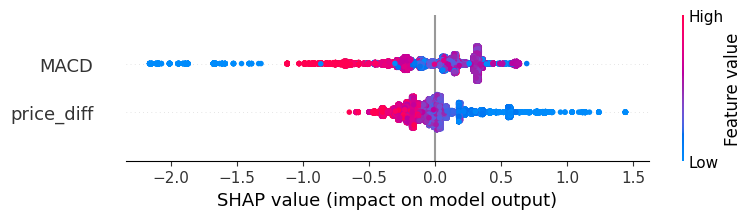

In [381]:
import shap
%matplotlib inline

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df_modelling[feature_cols])
shap.summary_plot(shap_values, df_modelling[feature_cols])
plt.show()

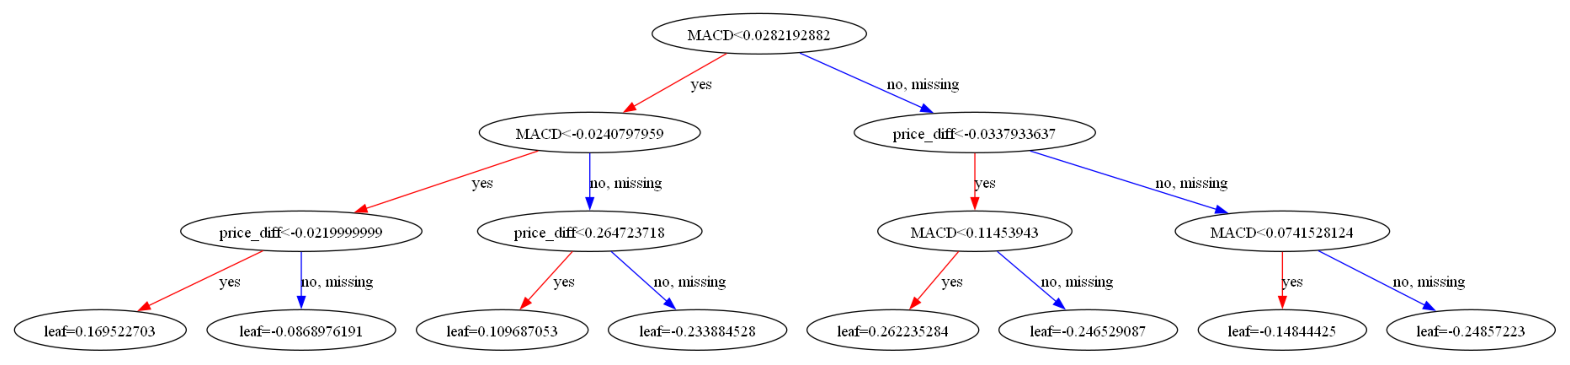

In [382]:
fig, ax = plt.subplots(figsize=(20, 20))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='UT', ax=ax)
plt.show()

#### **Precision curve**

In [383]:
preds_p = xgb_model.predict_proba(X_test[feature_cols])[:, 1]
#preds_p = model.predict(X_test).apply(lambda x: 1/(1+np.exp(-x)))

# threshold for more certainty in predicted values
thold_list = np.arange(0.2, 0.45, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [1 if x > thold else 0 for x in preds_p]
    cm = confusion_matrix(y_test, preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [384]:
prec_recall_df[-50:]

,thold,precision,recall,count
200,0.400,0.500283,0.432419,1765
201,0.401,0.500283,0.432419,1765
202,0.402,0.500283,0.432419,1765
203,0.403,0.500283,0.432419,1765
204,0.404,0.500283,0.432419,1765
205,0.405,0.563422,0.187071,678
206,0.406,0.563422,0.187071,678
207,0.407,0.563422,0.187071,678
208,0.408,0.563422,0.187071,678
209,0.409,0.563422,0.187071,678


### Interactions

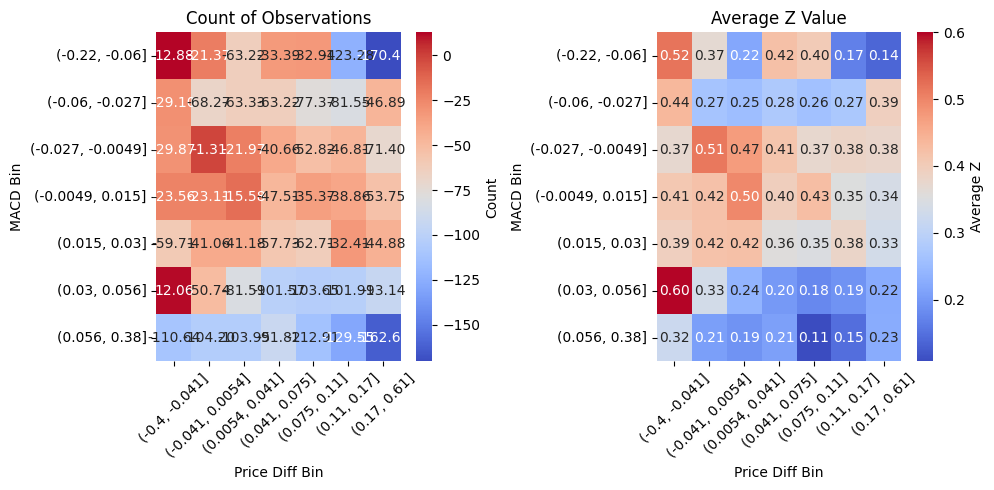

In [385]:
# Binning with interval labels
df_modelling.loc[:,'MACD_bin'] = pd.qcut(df_modelling['MACD'], 7, retbins=False, precision=2)
df_modelling.loc[:,'price_diff_bin'] = pd.qcut(df_modelling['price_diff'], 7, retbins=False, precision=2)


# Create pivot tables
count_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='profit_short', aggfunc='sum')
mean_pivot = df_modelling.pivot_table(index='MACD_bin', columns='price_diff_bin', values='y', aggfunc='mean')

# Setup figure for heatmaps
plt.figure(figsize=(10,5))

# Heatmap for count of observations
plt.subplot(1, 2, 1)
sns.heatmap(count_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Count'})
plt.title('Count of Observations')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(count_pivot.columns)) + 0.5, count_pivot.columns, rotation=45)
plt.yticks(np.arange(len(count_pivot.index)) + 0.5, count_pivot.index, rotation=0)

# Heatmap for average of Z
plt.subplot(1, 2, 2)
sns.heatmap(mean_pivot, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'label': 'Average Z'})
plt.title('Average Z Value')
plt.xlabel('Price Diff Bin')
plt.ylabel('MACD Bin')
plt.xticks(np.arange(len(mean_pivot.columns)) + 0.5, mean_pivot.columns, rotation=45)
plt.yticks(np.arange(len(mean_pivot.index)) + 0.5, mean_pivot.index, rotation=0)

plt.tight_layout()
plt.show()

In [386]:
count_pivot

price_diff_bin,"(-0.4, -0.041]","(-0.041, 0.0054]","(0.0054, 0.041]","(0.041, 0.075]","(0.075, 0.11]","(0.11, 0.17]","(0.17, 0.61]"
MACD_bin,,,,,,,
"(-0.22, -0.06]",12.880,-21.370,-63.215,-33.390,-32.935,-123.280,-170.475
"(-0.06, -0.027]",-29.100,-68.265,-63.325,-63.215,-77.365,-81.550,-46.890
"(-0.027, -0.0049]",-29.865,-1.310,-21.970,-40.660,-52.815,-46.810,-71.395
"(-0.0049, 0.015]",-23.555,-23.105,-15.575,-47.505,-35.370,-38.855,-53.745
"(0.015, 0.03]",-59.705,-41.060,-41.175,-57.730,-62.705,-32.410,-44.875
"(0.03, 0.056]",12.060,-50.740,-81.590,-101.565,-103.650,-101.910,-93.140
"(0.056, 0.38]",-110.640,-104.195,-103.950,-91.815,-112.910,-129.545,-162.600


In [387]:
mean_pivot

price_diff_bin,"(-0.4, -0.041]","(-0.041, 0.0054]","(0.0054, 0.041]","(0.041, 0.075]","(0.075, 0.11]","(0.11, 0.17]","(0.17, 0.61]"
MACD_bin,,,,,,,
"(-0.22, -0.06]",0.518315,0.367978,0.218097,0.422727,0.403651,0.167260,0.136827
"(-0.06, -0.027]",0.435065,0.266314,0.254237,0.276923,0.260788,0.274368,0.393229
"(-0.027, -0.0049]",0.371429,0.513514,0.473214,0.414894,0.374753,0.382883,0.378076
"(-0.0049, 0.015]",0.409369,0.420959,0.497512,0.395644,0.426160,0.352246,0.339066
"(0.015, 0.03]",0.392461,0.417339,0.421286,0.356383,0.348673,0.381783,0.333333
"(0.03, 0.056]",0.600000,0.332645,0.237069,0.198257,0.178000,0.190283,0.223320
"(0.056, 0.38]",0.322526,0.206349,0.191304,0.208955,0.107477,0.146535,0.226230
